In [ ]:
import json
import sys
import os
import time
import platform
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

%matplotlib inline

sys.path.append(os.path.abspath(".."))

from sklearn.datasets import load_svmlight_file

from src.oracles import LogCoshL2Oracle, ExponentialLossL2Oracle
from src.optimization import gradient_descent, newton


def sparse_oracle_ops(X):
    if not sp.issparse(X):
        X = sp.csr_matrix(X, dtype=np.float64)
    else:
        X = X.astype(np.float64).tocsr()

    def matvec_Ax(x):
        return X.dot(np.asarray(x, dtype=np.float64).ravel())

    def matvec_ATx(x):
        return X.T.dot(np.asarray(x, dtype=np.float64).ravel())

    def matmat_ATsA(s):
        s = np.asarray(s, dtype=np.float64).ravel()
        return X.T.dot(sp.diags(s) @ X)

    return matvec_Ax, matvec_ATx, matmat_ATsA


LAB1 = Path(os.path.abspath("..")).resolve()


LIBSVM_BASE = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets"

TOLERANCE = 1e-5
SKIP_GISETTE = False
GISETTE_MAX_FEATURES = None
SHOW_PLOTS = True

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "lines.linewidth": 2.8,
    "figure.figsize": (7.5, 4.8),
})

print("LAB1:", LAB1)


In [2]:
DATASETS = [
    {
        "name": "abalone_scale",
        "url": f"{LIBSVM_BASE}/regression/abalone_scale",
        "oracle": "logcosh",
        "newton_max_iter": 400,
        "gd_max_iter": 8000,
    },
    {
        "name": "bodyfat_scale",
        "url": f"{LIBSVM_BASE}/regression/bodyfat_scale",
        "oracle": "logcosh",
        "newton_max_iter": 400,
        "gd_max_iter": 8000,
    },
    {
        "name": "a9a",
        "url": f"{LIBSVM_BASE}/binary/a9a",
        "oracle": "exp",
        "newton_max_iter": 400,
        "gd_max_iter": 8000,
    },
    {
        "name": "gisette_scale.bz2",
        "url": f"{LIBSVM_BASE}/binary/gisette_scale.bz2",
        "oracle": "exp",
        "newton_max_iter": 80,
        "gd_max_iter": 25000,
        "note": "Полный gisette 6000×5000; опционально GISETTE_MAX_FEATURES.",
    },
]


def find_data_dir() -> Path:
    for base in (LAB1, LAB1.parent, Path.cwd().resolve()):
        d = base / "data" / "libsvm"
        if d.is_dir():
            return d
    d = LAB1 / "data" / "libsvm"
    d.mkdir(parents=True, exist_ok=True)
    return d


def download_file(url: str, dest: Path) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    print("  загрузка:", dest.name)
    req = urllib.request.Request(url, headers={"User-Agent": "MetOpt-lab/1.0"})
    with urllib.request.urlopen(req, timeout=300) as r, open(dest, "wb") as f:
        f.write(r.read())


def ensure_dataset(path: Path, url: str) -> None:
    if not path.is_file():
        download_file(url, path)


def labels_pm_one(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float).ravel()
    u = np.unique(y)
    if len(u) == 2 and 0.0 in u and 1.0 in u:
        return 2.0 * y - 1.0
    return y


def run_pair(oracle, x0, tol, gd_max, nt_max):
    ls = {"method": "Wolfe", "c1": 1e-4, "c2": 0.9}
    t0 = time.perf_counter()
    xg, msg_g, hg = gradient_descent(
        oracle, x0, tolerance=tol, line_search_options=ls, trace=True, max_iter=gd_max
    )
    t_gd = time.perf_counter() - t0
    t0 = time.perf_counter()
    xn, msg_n, hn = newton(
        oracle, x0, tolerance=tol, line_search_options=ls, trace=True, max_iter=nt_max
    )
    t_nt = time.perf_counter() - t0
    return (xg, msg_g, hg, t_gd), (xn, msg_n, hn, t_nt)


def plot_experiment(stem: str, hist_g, hist_n, msg_g, msg_n):
    tg = np.asarray(hist_g["time"], dtype=float)
    tn = np.asarray(hist_n["time"], dtype=float)
    fg = np.asarray(hist_g["func"])
    fn = np.asarray(hist_n["func"])
    g0sq = float(hist_g["grad_norm"][0] ** 2)
    rg = (np.asarray(hist_g["grad_norm"], dtype=float) ** 2) / max(g0sq, 1e-30)
    rn = (np.asarray(hist_n["grad_norm"], dtype=float) ** 2) / max(g0sq, 1e-30)
    safe = stem.replace(".", "_")

    fig, ax = plt.subplots()
    ax.semilogy(tg, np.maximum(fg, 1e-300), label=f"градиентный спуск ({msg_g})")
    ax.semilogy(tn, np.maximum(fn, 1e-300), label=f"Ньютон ({msg_n})")
    ax.set_xlabel("Время, с")
    ax.set_ylabel(r"$f(x_k)$")
    ax.set_title(stem + ": значение целевой функции")
    ax.legend()
    ax.grid(True, which="both", alpha=0.4)
    fig.tight_layout()
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

    fig, ax = plt.subplots()
    ax.semilogy(tg, rg, label=f"градиентный спуск ({msg_g})")
    ax.semilogy(tn, rn, label=f"Ньютон ({msg_n})")
    ax.set_xlabel("Время, с")
    ax.set_ylabel("‖∇f(x_k)‖₂² / ‖∇f(x₀)‖₂²  (отн.)")
    ax.set_title(stem + ": относительный квадрат нормы градиента")
    ax.legend()
    ax.grid(True, which="both", alpha=0.4)
    fig.tight_layout()
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


DATA_DIR: C:\D\Code\MetOpt\lab1\data\libsvm

abalone_scale: m=4177, n=8, nnz=32080, density=0.96


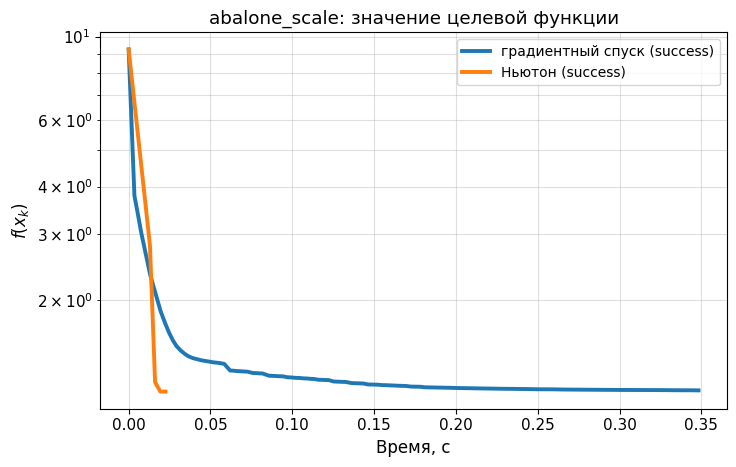

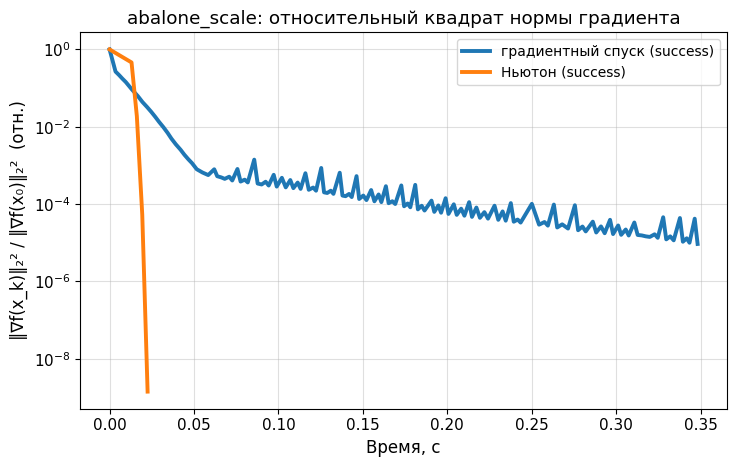

  GD: success, iters=142, time=0.35s
  Newton: success, iters=4, time=0.02s

bodyfat_scale: m=252, n=14, nnz=3528, density=1


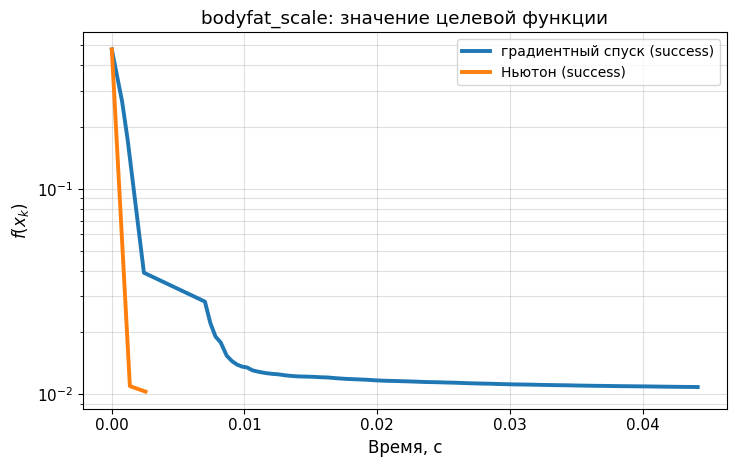

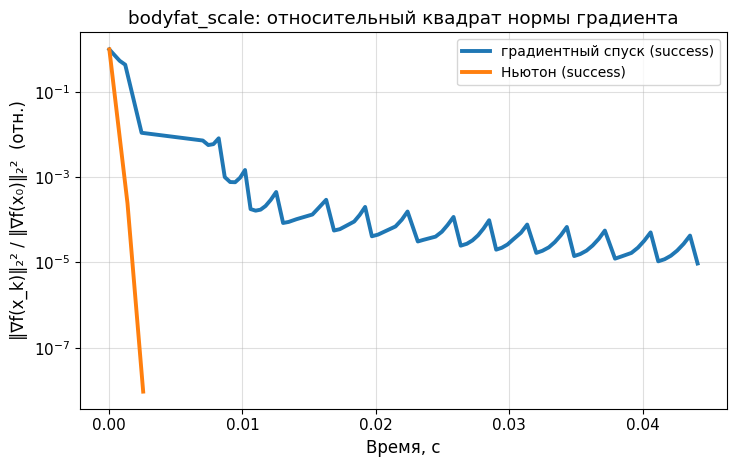

  GD: success, iters=79, time=0.04s
  Newton: success, iters=2, time=0.00s

a9a: m=32561, n=123, nnz=451592, density=0.1128


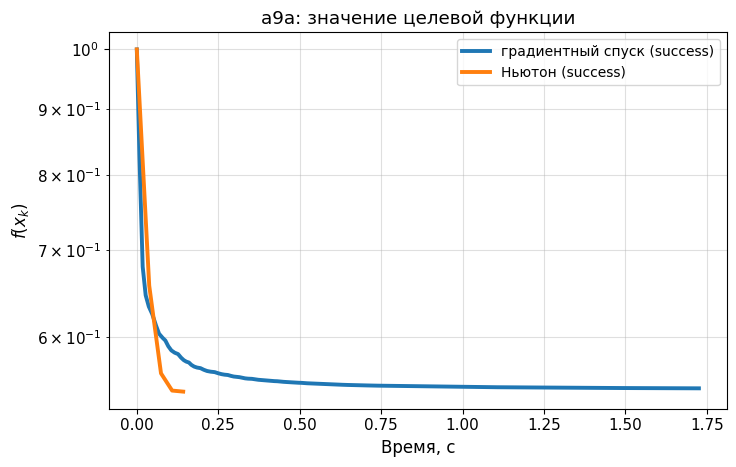

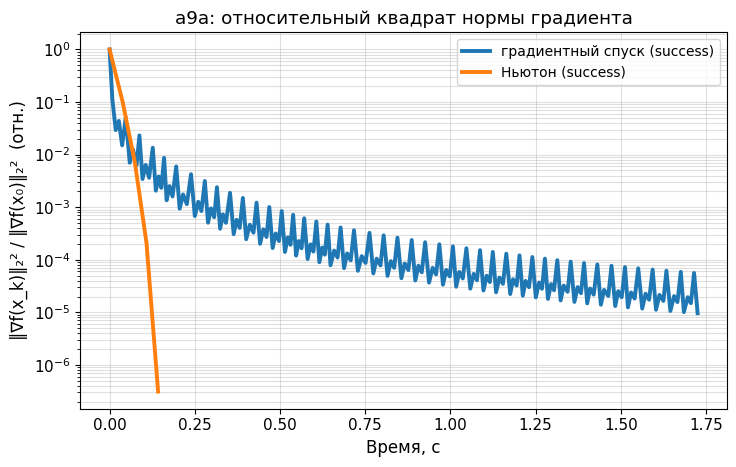

  GD: success, iters=178, time=1.73s
  Newton: success, iters=4, time=0.15s

gisette_scale.bz2: m=6000, n=5000, nnz=29729997, density=0.991


c:\Users\korel\anaconda3\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


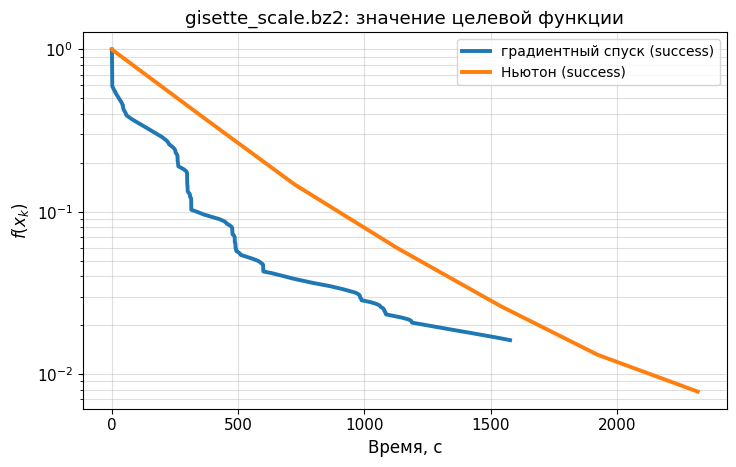

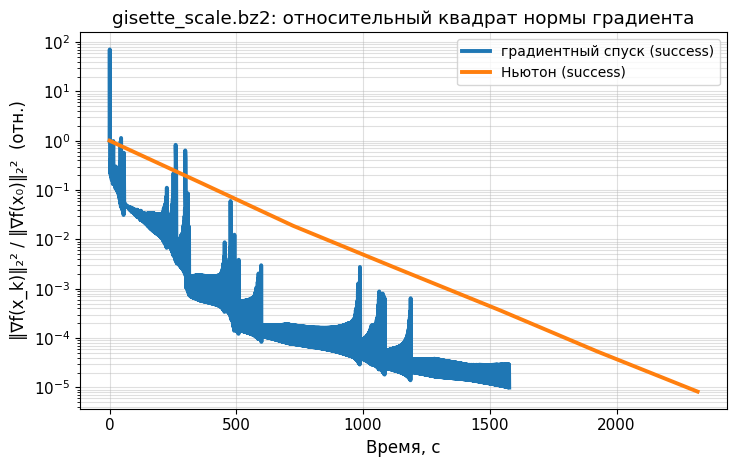

  GD: success, iters=1874, time=1576.94s
  Newton: success, iters=6, time=2320.16s

Метаданные: C:\D\Code\MetOpt\lab1\report\experiment_3_4_meta.json
Графики: C:\D\Code\MetOpt\lab1\report\figures


In [3]:
data_dir = find_data_dir()
print("DATA_DIR:", data_dir)

meta = {
    "tolerance": TOLERANCE,
    "lambda_rule": "1/m",
    "x0": "zeros",
    "line_search": "Wolfe c1=1e-4 c2=0.9",
    "platform": platform.platform(),
    "processor": platform.processor(),
    "datasets": [],
}

cfgs = [c for c in DATASETS if not (SKIP_GISETTE and "gisette" in c["name"])]

for cfg in cfgs:
    name = cfg["name"]
    path = data_dir / name
    cap = None
    try:
        ensure_dataset(path, cfg["url"])
    except Exception as e:
        print(f"Пропуск {name}: загрузка ({e})")
        meta["datasets"].append({"name": name, "error": str(e)})
        continue

    try:
        X, y = load_svmlight_file(str(path))
        X = X.tocsr()
        n_full = int(X.shape[1])
        if "gisette" in cfg["name"] and GISETTE_MAX_FEATURES is not None:
            cap = int(min(GISETTE_MAX_FEATURES, n_full))
            X = X[:, :cap].tocsr()
    except Exception as e:
        print(f"Пропуск {name}: чтение ({e})")
        meta["datasets"].append({"name": name, "error": str(e)})
        continue

    m, n = X.shape
    nnz = X.nnz
    density = nnz / max(m * n, 1)
    y = labels_pm_one(y)
    reg = 1.0 / m
    mvx, mvt, mm = sparse_oracle_ops(X)

    if cfg["oracle"] == "logcosh":
        oracle = LogCoshL2Oracle(mvx, mvt, mm, y, regcoef=reg)
    else:
        oracle = ExponentialLossL2Oracle(mvx, mvt, mm, y, regcoef=reg)

    x0 = np.zeros(n)
    print()
    print(f"{name}: m={m}, n={n}, nnz={nnz}, density={density:.4g}")

    (xg, msg_g, hg, wg), (xn, msg_n, hn, wn) = run_pair(
        oracle, x0, TOLERANCE, cfg["gd_max_iter"], cfg["newton_max_iter"]
    )
    plot_experiment(name, hg, hn, msg_g, msg_n)

    entry = {
        "name": name,
        "m": int(m),
        "n": int(n),
        "nnz": int(nnz),
        "density": float(density),
        "oracle": cfg["oracle"],
        "gd_message": msg_g,
        "newton_message": msg_n,
        "wall_clock_gd_s": wg,
        "wall_clock_newton_s": wn,
        "gd_iters": len(hg["func"]) - 1,
        "newton_iters": len(hn["func"]) - 1,
        "f_final_gd": float(oracle.func(xg)),
        "f_final_newton": float(oracle.func(xn)),
    }
    if "note" in cfg:
        entry["note"] = cfg["note"]
    if cap is not None:
        entry["n_full_libsvm"] = n_full
        entry["n_used"] = int(X.shape[1])
    meta["datasets"].append(entry)
    print(f"  GD: {msg_g}, iters={entry['gd_iters']}, time={wg:.2f}s")
    print(f"  Newton: {msg_n}, iters={entry['newton_iters']}, time={wn:.2f}s")

print()
